
# Taller 2 — Física Computacional

**CRISTIAN ANDRÉS CÁRDENAS MUÑOZ**

Hola profe, aqui esta la solucion del taller 2 como la pediste.

## Parte A — Aproximación de \(\sin(x)\) mediante serie de Taylor

Se utiliza la forma recursiva de la serie:

$$
t_0=x,
\qquad
t_n=-t_{n-1}\frac{x^2}{(2n)(2n+1)}
$$

y el criterio de parada

$$
|t_n|<\text{tol}\,\max(1,|S_n|).
$$

In [14]:

import math
import time
import numpy as np
import matplotlib.pyplot as plt


In [2]:

def suma_seno(x, tol=1e-8, max_iter=200):
    """Aproxima sin(x) usando la serie de Taylor en forma recursiva."""
    term = x
    suma = x

    for n in range(1, max_iter + 1):
        term = -term * x**2 / ((2*n) * (2*n + 1))
        suma += term

        if abs(term) < tol * max(1.0, abs(suma)):
            return suma, n

    return suma, max_iter



### 1. Tabla de convergencia

Se comparan seis valores entre \(0\) y \(4\pi\) contra `math.sin(x)`.


In [3]:

valores_x = [0.5, 1.0, 2.0, 3.0, 6.0, 4*math.pi]

print(f"{'x':>12} {'iter':>6} {'suma':>18} {'math.sin(x)':>18} {'error relativo':>18}")
print("-" * 80)

for x in valores_x:
    aproximado, iteraciones = suma_seno(x)
    referencia = math.sin(x)
    error_abs = abs(aproximado - referencia)

    if abs(referencia) > 1e-15:
        error_rel = error_abs / abs(referencia)
        error_texto = f"{error_rel:.3e}"
    else:
        error_texto = "no estable"

    print(
        f"{x:12.8f} {iteraciones:6d} "
        f"{aproximado:18.10e} {referencia:18.10e} {error_texto:>18}"
    )


           x   iter               suma        math.sin(x)     error relativo
--------------------------------------------------------------------------------
  0.50000000      4   4.7942553862e-01   4.7942553860e-01          2.547e-11
  1.00000000      6   8.4147098481e-01   8.4147098481e-01          9.055e-13
  2.00000000      8   9.0929742683e-01   9.0929742683e-01          4.695e-12
  3.00000000      9   1.4112000786e-01   1.4112000806e-01          1.425e-09
  6.00000000     14  -2.7941549804e-01  -2.7941549820e-01          5.582e-10
 12.56637061     24   6.8575568718e-11  -4.8985871966e-16         no estable



Para valores alejados de los ceros del seno, el error relativo es muy pequeño y compatible con la tolerancia usada.

En \(x=4\pi\), `math.sin(4*pi)` es numéricamente casi cero. En ese caso el error relativo deja de ser una medida útil porque se divide por un valor extremadamente pequeño. Cerca de cero es más apropiado observar el error absoluto.



### 2. Argumento grande sin reducción


In [4]:

x_grande = 100.0

aproximado_directo, iter_directas = suma_seno(x_grande)
referencia_directa = math.sin(x_grande)

print("x =", x_grande)
print("Serie directa :", aproximado_directo)
print("math.sin(x)   :", referencia_directa)
print("Iteraciones   :", iter_directas)
print("Error absoluto:", abs(aproximado_directo - referencia_directa))


x = 100.0
Serie directa : -8.261375671717164e+25
math.sin(x)   : -0.5063656411097588
Iteraciones   : 111
Error absoluto: 8.261375671717164e+25



Para \(x=100\), los términos intermedios de Taylor alcanzan magnitudes muy grandes antes de cancelarse. En aritmética de punto flotante esa cancelación provoca pérdida de dígitos significativos, por lo que la suma directa puede dar un resultado incorrecto.



### 3. Reducción del argumento


In [5]:

def suma_seno_reducida(x, tol=1e-8, max_iter=200):
    """Reduce x usando la periodicidad del seno y luego evalúa la serie."""
    x_reducido = math.remainder(x, 2 * math.pi)
    return suma_seno(x_reducido, tol, max_iter)


In [6]:

for x in [50.0, 100.0, -237.0]:
    aproximado, iteraciones = suma_seno_reducida(x)
    referencia = math.sin(x)

    print(
        f"x={x:8.1f} | aproximado={aproximado: .12f} | "
        f"referencia={referencia: .12f} | "
        f"error={abs(aproximado-referencia):.3e} | iter={iteraciones}"
    )


x=    50.0 | aproximado=-0.262374853704 | referencia=-0.262374853704 | error=9.603e-15 | iter=4
x=   100.0 | aproximado=-0.506365641133 | referencia=-0.506365641110 | error=2.364e-11 | iter=4
x=  -237.0 | aproximado= 0.981957869740 | referencia= 0.981957869782 | error=4.198e-11 | iter=7



La reducción con `math.remainder(x, 2*pi)` lleva el argumento a un intervalo cercano a \([-\pi,\pi]\). Esto mantiene los términos de la serie pequeños y mejora de forma importante la estabilidad numérica.



### 4. Implementación recursiva vs. implementación ingenua


In [7]:

def suma_seno_ingenua(x, tol=1e-8, max_iter=200):
    """Calcula cada término desde cero usando potencias y factoriales."""
    suma = 0.0

    for n in range(max_iter):
        term = ((-1)**n) * x**(2*n + 1) / math.factorial(2*n + 1)
        suma += term

        if abs(term) < tol * max(1.0, abs(suma)):
            return suma, n + 1

    return suma, max_iter


def tiempo_promedio(funcion, x, repeticiones=1000):
    inicio = time.perf_counter()
    for _ in range(repeticiones):
        funcion(x)
    return (time.perf_counter() - inicio) / repeticiones


In [8]:

print(f"{'x':>6} {'err recursiva':>16} {'err ingenua':>16} {'t rec (us)':>12} {'t ing (us)':>12}")
print("-" * 72)

for x in [1.0, 10.0, 20.0, 30.0, 50.0]:
    valor_rec, _ = suma_seno(x)
    valor_ing, _ = suma_seno_ingenua(x)
    referencia = math.sin(x)

    error_rec = abs(valor_rec - referencia)
    error_ing = abs(valor_ing - referencia)

    t_rec = tiempo_promedio(suma_seno, x) * 1e6
    t_ing = tiempo_promedio(suma_seno_ingenua, x) * 1e6

    print(
        f"{x:6.1f} {error_rec:16.3e} {error_ing:16.3e} "
        f"{t_rec:12.3f} {t_ing:12.3f}"
    )


     x    err recursiva      err ingenua   t rec (us)   t ing (us)
------------------------------------------------------------------------
   1.0        7.619e-13        7.619e-13        5.946        7.995
  10.0        1.571e-10        1.576e-10       10.816       24.429
  20.0        4.878e-09        2.921e-09       42.109       62.908
  30.0        4.180e-05        3.177e-05       27.062       92.466
  50.0        1.557e+04        2.747e+04       45.762       97.208



La versión recursiva evita volver a calcular factoriales y potencias en cada término. Para argumentos pequeños ambas formas producen resultados parecidos, pero la recursiva es más eficiente.

Cuando \(|x|\) crece mucho, las dos versiones sin reducción pierden precisión porque aparecen términos intermedios enormes. Por eso la combinación más adecuada es: **recurrencia + reducción del argumento**.


## Parte B — Decaimiento radiactivo

El modelo es

$$
N(t)=N_0e^{-\lambda t},
\qquad
\lambda=\frac{\ln 2}{t_{1/2}}
$$

con:

$$
N_0=10000,
\qquad
t_{1/2}=5\text{ años}.
$$

In [9]:

N0 = 10000
t_half = 5.0
lambda_decaimiento = np.log(2) / t_half

tiempos = np.linspace(0.0, 30.0, 301)

# Cálculo vectorizado: no se usa un ciclo para calcular N(t).
N = N0 * np.exp(-lambda_decaimiento * tiempos)

print(f"lambda = {lambda_decaimiento:.8f} 1/año")
print(f"N(0)  = {N0:.0f}")
print(f"N(5)  = {N0*np.exp(-lambda_decaimiento*5):.2f}")
print(f"N(10) = {N0*np.exp(-lambda_decaimiento*10):.2f}")
print(f"N(15) = {N0*np.exp(-lambda_decaimiento*15):.2f}")


lambda = 0.13862944 1/año
N(0)  = 10000
N(5)  = 5000.00
N(10) = 2500.00
N(15) = 1250.00


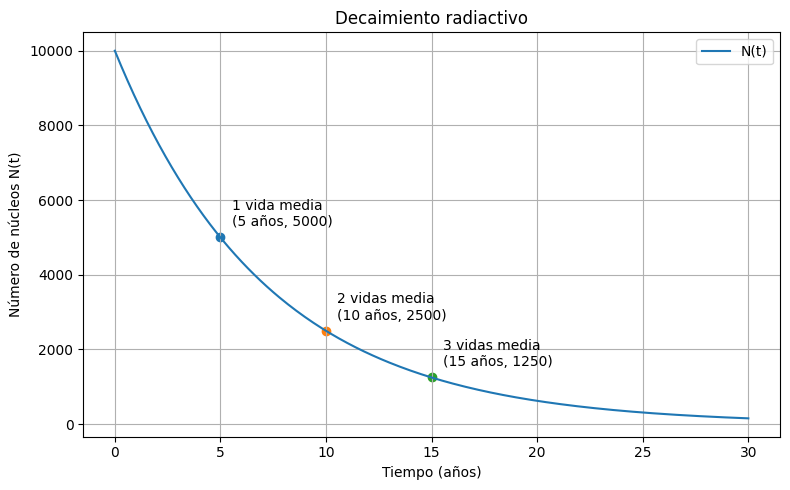

In [10]:

plt.figure(figsize=(8, 5))
plt.plot(tiempos, N, label="N(t)")

for k in [1, 2, 3]:
    t_marca = k * t_half
    N_marca = N0 * np.exp(-lambda_decaimiento * t_marca)

    plt.scatter(t_marca, N_marca)
    plt.annotate(
        f"{k} vida{'s' if k > 1 else ''} media\n"
        f"({t_marca:.0f} años, {N_marca:.0f})",
        (t_marca, N_marca),
        textcoords="offset points",
        xytext=(8, 8)
    )

plt.title("Decaimiento radiactivo")
plt.xlabel("Tiempo (años)")
plt.ylabel("Número de núcleos N(t)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


### Tiempo para 50 %, 25 % y 10 %

A partir de

$$
\frac{N(t)}{N_0}=f
$$

se despeja

$$
t=-\frac{\ln(f)}{\lambda}.
$$

In [11]:

fracciones = np.array([0.50, 0.25, 0.10])
tiempos_fracciones = -np.log(fracciones) / lambda_decaimiento

for fraccion, t_valor in zip(fracciones, tiempos_fracciones):
    print(f"{100*fraccion:5.1f}% -> {t_valor:.4f} años")


 50.0% -> 5.0000 años
 25.0% -> 10.0000 años
 10.0% -> 16.6096 años



Los resultados son:

- 50 % de la muestra: 5 años.
- 25 % de la muestra: 10 años.
- 10 % de la muestra: aproximadamente 16.61 años.

El cálculo de \(N(t)\) se realizó de forma vectorizada con NumPy, lo que evita un ciclo innecesario y mantiene el código cercano a la ecuación física.



## Verificación PASS/FAIL


In [12]:

# Parte A
casos_a = [0.5, 100.0, -237.0]

for x in casos_a:
    obtenido, _ = suma_seno_reducida(x)
    esperado = math.sin(x)
    ok = abs(obtenido - esperado) < 1e-8
    print(f"{'PASS' if ok else 'FAIL'}  x={x:8.1f}")


PASS  x=     0.5
PASS  x=   100.0
PASS  x=  -237.0


In [13]:

# Parte B
def N_decaimiento(t, N0=10000, t_half=5.0):
    lambda_ = math.log(2.0) / t_half
    return N0 * math.exp(-lambda_ * t)

casos_b = [
    (0.0, 1.00),
    (5.0, 0.50),
    (10.0, 0.25),
]

for t, fraccion_esperada in casos_b:
    obtenido = N_decaimiento(t) / 10000
    ok = abs(obtenido - fraccion_esperada) < 1e-3
    print(
        f"{'PASS' if ok else 'FAIL'}  "
        f"t={t:>5.1f} años   "
        f"fraccion={obtenido:.3f}   "
        f"esperada={fraccion_esperada:.3f}"
    )


PASS  t=  0.0 años   fraccion=1.000   esperada=1.000
PASS  t=  5.0 años   fraccion=0.500   esperada=0.500
PASS  t= 10.0 años   fraccion=0.250   esperada=0.250
